# Simulating Credit Portfolios: from VBA Loops to Vectorized Python

### **Maurilio Patiño García**  

---

## Context

This is the second installment in a series on credit risk modeling. In the [first post](https://www.linkedin.com/posts/mauriliopatino_why-does-the-basel-ii-irb-formula-work-activity-7443070475855024128-UJR8?utm_source=share&utm_medium=member_desktop&rcm=ACoAAADlkmMBU5ZiE6--O0JSx_COyOBVp73npqY), we asked a seemingly simple question: *why does the Basel II IRB formula work?* The answer turned out to rest on three ideas — conditional independence, the law of large numbers, and monotonicity — which together prove that the VaR of a granular credit portfolio has a closed-form solution:

$$
\lim_{N\to\infty} VaR_\alpha(L_N) = \mathbb{E}\left[L_N \,\middle|\, Z = \Phi^{-1}(\alpha)\right]
= \sum_{i=1}^{N} \ell_i \;\Phi\!\left(\frac{\Phi^{-1}(PD_i) + \sqrt{\rho_i}\,\Phi^{-1}(\alpha)}{\sqrt{1-\rho_i}}\right)
$$

That formula is elegant and exact. But it only works under specific conditions: a single systematic factor, Gaussian dependence, and a portfolio large and diversified enough for idiosyncratic risk to vanish. In practice, we routinely encounter situations where one or more of these conditions fail:

- **Concentrated portfolios** where a few large exposures prevent the law of large numbers from doing its job.
- **Multi-factor models** where geographic or sectoral concentration requires more than one systematic driver.
- **Non-Gaussian factors** (e.g., $t$-distributed) where heavier tails change the shape of the loss distribution.
- **Path-dependent features** — prepayment, cure from delinquency, time-varying PDs — that break the static one-period framework.
- **Stress testing** where the regulator prescribes specific macroeconomic scenarios that do not fit neatly into the model's distributional assumptions.

In all of these cases, the closed-form formula is no longer available and we must resort to **Monte Carlo simulation** to estimate the loss distribution and its percentiles.

## Motivation

Monte Carlo is conceptually straightforward: simulate many scenarios, compute the portfolio loss in each one, and extract the percentile you need. The challenge is **computational**: estimating a 99.9th percentile — the confidence level mandated by Basel II — means we need accurate information about events that occur only once in a thousand scenarios. Plain Monte Carlo is wasteful here: 99.9% of the simulated scenarios fall below the quantile and contribute nothing to its estimation.

This notebook addresses that challenge. We implement and compare three increasingly sophisticated simulation strategies:

1. **Plain Monte Carlo** — the baseline. Draw random scenarios, sort the losses, take the percentile.
2. **Importance Sampling (IS)** — shift the sampling distribution toward the tail so that more scenarios contribute useful information.
3. **IS + Quasi-Monte Carlo (QMC)** — replace pseudorandom draws with a low-discrepancy Halton sequence that covers the factor space more uniformly, doubling the convergence rate.

The implementation follows the framework of **Löffler & Posch** (*Credit Risk Modeling using Excel and VBA*, Wiley, 2nd ed., Chapter 7), who present these three methods as VBA macros operating on an Excel spreadsheet. This notebook translates their code into **vectorized Python** using NumPy and SciPy — no loops over individual credits, no Excel dependencies, and each estimator fits in about 20 lines.

We use the exact Basel formula as our **ground truth**: since the synthetic portfolio is granular ($N = 5{,}000$), the formula gives the correct VaR, and any deviation of the MC estimator from it is pure estimation error. This lets us measure precisely how fast each method converges, and by how much IS and QMC accelerate the process.

**Requirements:** `numpy`, `scipy`, `matplotlib`, `pandas`

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

MASTER_SEED = 2026

# Compatible trapezoidal integration (NumPy 1.x and 2.x)
trapz_fn = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

print('Libraries loaded.')
print(f'NumPy {np.__version__}')

Libraries loaded.
NumPy 2.4.3


## 1. Synthetic Mortgage Portfolio

| Parameter | Range | Rationale |
|-----------|-------|-----------|
| $PD_i$ | 0.5% – 5.0% | Through-the-cycle default probabilities |
| $LGD_i$ | 20% – 45% | After recovery via property sale |
| $EAD_i$ | 500K – 3M MXN | Typical outstanding balances |
| $\rho$ | 15% | Basel II residential mortgage correlation |

In [2]:
# === 1. SYNTHETIC PORTFOLIO ===
N = 5_000
rho = 0.15

w  = np.sqrt(rho)
w2 = np.sqrt(1 - rho)

rng_port = np.random.default_rng(42)
PD  = rng_port.uniform(0.005, 0.05, N)
LGD = rng_port.uniform(0.20, 0.45, N)
EAD = rng_port.uniform(500_000, 3_000_000, N)

d  = norm.ppf(PD)
lg = LGD * EAD

print(f'Portfolio: {N:,} credits')
print(f'Asset correlation rho = {rho:.0%}')
print(f'Total EAD          = {EAD.sum():>20,.0f}')
print(f'Avg PD             = {PD.mean():>20.2%}')
print(f'Avg LGD            = {LGD.mean():>20.2%}')
print(f'Expected Loss (EL) = {(PD * lg).sum():>20,.0f}')

Portfolio: 5,000 credits
Asset correlation rho = 15%
Total EAD          =        8,770,187,326
Avg PD             =                2.73%
Avg LGD            =               32.47%
Expected Loss (EL) =           78,166,782


## 2. The Exact Basel Formula (Convergence Target)

$$
VaR_\alpha = \sum_{i=1}^{N} LGD_i \cdot EAD_i \cdot
\Phi\!\left(\frac{\Phi^{-1}(PD_i) + \sqrt{\rho}\,\Phi^{-1}(\alpha)}{\sqrt{1-\rho}}\right)
$$

This is the **conditional expected loss** at the adverse scenario
$Z^* = \Phi^{-1}(\alpha) = 3.09$.

In [3]:
# === 2. EXACT FORMULA ===
alpha = 0.999
z_alpha = norm.ppf(alpha)

PD_stressed = norm.cdf((d + w * z_alpha) / w2)
L_exact = float((PD_stressed * lg).sum())
EL = float((PD * lg).sum())

print(f'Confidence level alpha = {alpha:.3%}')
print(f'Adverse factor  Z*     = {z_alpha:.4f}')
print()
print(f'Expected Loss (EL)     = {EL:>20,.0f}')
print(f'Exact VaR(99.9%)       = {L_exact:>20,.0f}')
print(f'Unexpected Loss (UL)   = {L_exact - EL:>20,.0f}')
print(f'VaR / EL               = {L_exact / EL:>20.2f}x')

Confidence level alpha = 99.900%
Adverse factor  Z*     = 3.0902

Expected Loss (EL)     =           78,166,782
Exact VaR(99.9%)       =          593,716,870
Unexpected Loss (UL)   =          515,550,088
VaR / EL               =                 7.60x


## 3. Conditional Loss Function $\mathbb{E}[L \mid Z]$

In the previous section we computed VaR(99.9%) using the closed-form Basel formula. That formula evaluates the conditional expected loss at a single, specific value of $Z$: the adverse scenario $z^* = \Phi^{-1}(\alpha)$.

But when we simulate, we do not get to choose $Z$. Instead, we draw many values of $Z$ at random, compute the portfolio loss for each one, and build up an empirical distribution from which we extract the percentile. The question is: **what exactly do we compute for each draw of $Z$?**

In a full Monte Carlo simulation (as in the VBA code of Löffler & Posch, Chapter 7), we would simulate each individual default: draw $Z$, then draw $\varepsilon_i$ for every credit, check whether $A_i = \sqrt{\rho}\,Z + \sqrt{1-\rho}\,\varepsilon_i < d_i$, and sum up the losses of the credits that defaulted. This is expensive — for each scenario we need $N = 5{,}000$ random draws plus $N$ comparisons — and it introduces **idiosyncratic noise**: even for the same $Z$, different draws of $\varepsilon_i$ produce different portfolio losses.

There is a shortcut. For a given value of $Z = z$, the conditional default probability of credit $i$ is known exactly:

$$PD_i(z) = P(A_i \leq d_i \mid Z = z) = \Phi\!\left(\frac{d_i + \sqrt{\rho}\,z}{\sqrt{1-\rho}}\right)$$

This follows directly from the model: given $Z = z$, the asset value $A_i = \sqrt{\rho}\,z + \sqrt{1-\rho}\,\varepsilon_i$ is normal with mean $\sqrt{\rho}\,z$ and variance $1-\rho$, and the default event $A_i \leq d_i$ has exactly this probability.

The **conditional expected loss** is then:

$$\mathbb{E}[L \mid Z = z] = \sum_{i=1}^{N} \ell_i \cdot PD_i(z) = \sum_{i=1}^{N} LGD_i \cdot EAD_i \;\Phi\!\left(\frac{d_i + \sqrt{\rho}\,z}{\sqrt{1-\rho}}\right)$$

This is the loss we **expect** if the economy is in state $z$, before we know which specific credits default.

### Why can we use $\mathbb{E}[L|Z]$ instead of simulating individual defaults?

In a portfolio of $N = 5{,}000$ credits with broadly similar exposures, the **Law of Large Numbers** guarantees that the actual portfolio loss (with its random individual defaults) is very close to the conditional expected loss, for each realization of $Z$:

$$L(Z) = \sum_{i=1}^{N} \ell_i \cdot \mathbf{1}\{A_i \leq d_i\} \;\approx\; \mathbb{E}[L \mid Z] \quad \text{(for large, granular } N\text{)}$$

The idiosyncratic shocks $\varepsilon_i$ average out across thousands of credits. What remains is the systematic component — the state of the economy, captured entirely by $Z$.

This is the same result we proved in Post 1 (Proposition 2.5.4 of Bluhm, Overbeck & Wagner): for a granular portfolio, portfolio loss is essentially a **deterministic function of $Z$**.

### What this buys us

By replacing the full simulation (draw $Z$, draw $N$ epsilons, check $N$ defaults, sum losses) with a single function evaluation $\mathbb{E}[L|Z]$, we achieve two things:

1. **Speed.** Each scenario requires one call to `cond_loss(z)` instead of generating and processing 5,000 random variables. This is what makes the convergence study feasible on a laptop.

2. **Isolation of the estimation problem.** The only remaining source of Monte Carlo error is how well we sample $Z$. All idiosyncratic noise is gone. This is exactly the dimension where Importance Sampling and Quasi-Monte Carlo make their difference — they improve how we explore the space of the systematic factor, not the idiosyncratic noise that the LLN already eliminated.

### Monotonicity

The function $\mathbb{E}[L|Z = z]$ is **strictly increasing** in $z$. This is because $\Phi\!\left(\frac{d_i + \sqrt{\rho}\,z}{\sqrt{1-\rho}}\right)$ is increasing in $z$ for every credit $i$: a higher $z$ means a worse macroeconomic realization, which pushes every individual default probability upward.

This monotonicity is what allows us to identify the VaR directly with a quantile of $Z$: the 99.9th percentile of the loss distribution corresponds to $z^* = \Phi^{-1}(0.999) = +3.09$, a value in the **right tail** of the standard normal. This sign convention matters for Importance Sampling — the shift must be positive.

In [25]:
# === 3. CONDITIONAL LOSS FUNCTION (batched) ===

# Adjust BATCH_SIZE to your available RAM:
#   200 -> ~15 MB per batch (safe for most machines)
#   500 -> ~38 MB per batch
BATCH_SIZE = 200

def cond_loss(Z_values):
    '''
    Compute E[L|Z] for each Z value.
    Batched to avoid allocating a full (M x N) matrix.
    '''
    Z_values = np.atleast_1d(Z_values)
    M = len(Z_values)
    result = np.empty(M)

    for start in range(0, M, BATCH_SIZE):
        end = min(start + BATCH_SIZE, M)
        Z_b = Z_values[start:end]
        pd_cond = norm.cdf((d[None, :] + w * Z_b[:, None]) / w2)
        result[start:end] = (pd_cond * lg[None, :]).sum(axis=1)
        del pd_cond

    return result


# Verification
check = cond_loss(np.array([z_alpha]))[0]
print(f'E[L | Z = {z_alpha:.4f}] = {check:,.0f}')
print(f'Exact formula           = {L_exact:,.0f}')
print(f'Match: {np.isclose(check, L_exact)}')

E[L | Z = 3.0902] = 593,716,870
Exact formula           = 593,716,870
Match: True


## 4. Plain Monte Carlo

### The estimator

The simplest approach to estimating $VaR_\alpha$. We draw $M$ independent scenarios $Z_1, \ldots, Z_M \sim N(0,1)$, compute the conditional expected loss $\mathbb{E}[L|Z_j]$ for each one, sort them from smallest to largest, and pick the observation at position $\lceil \alpha M \rceil$:

$$\widehat{VaR}_\alpha^{MC} = L_{(\lceil \alpha M \rceil)}$$

where $L_{(k)}$ denotes the $k$-th order statistic (the $k$-th smallest value in the sorted list).

For example, with $M = 10{,}000$ and $\alpha = 0.999$, we sort the 10,000 losses and take the value at position 9,990. The VaR estimate is literally the 10th largest loss in the sample.

### How fast does it converge?

There is a classical result (Bahadur, 1966) that tells us how much estimation error to expect from the empirical quantile. For large $M$, the variance of the estimator is:

$$\text{Var}\!\left(\widehat{VaR}_\alpha^{MC}\right) = \frac{\alpha(1-\alpha)}{M \, f_L(VaR_\alpha)^2}$$

where $f_L$ is the probability density of $L$ evaluated at the true quantile.

Two things follow immediately:

**The convergence rate is $O(1/\sqrt{M})$.** This comes from the Central Limit Theorem applied to the empirical quantile. To **halve** the estimation error, you need **four times** as many simulations. Going from 5% error to 1% error requires a 25-fold increase in $M$.

**The error gets worse in the tail.** As $\alpha \to 1$, the density $f_L(VaR_\alpha)$ shrinks because there is less and less probability mass in the region we are trying to estimate. For $\alpha = 0.999$ with $M = 10{,}000$, we expect only about 10 simulated losses above the true quantile. The estimator essentially depends on the 10th observation from the maximum — not a lot of information to work with.

This is the fundamental limitation that motivates Importance Sampling: most of the $M$ simulations produce losses well below the quantile and contribute nothing to its estimation. We need a way to concentrate our computational effort in the tail.

In [14]:
# === 4. PLAIN MONTE CARLO ===

def var_plain_mc(M, seed):
    '''
    Plain MC estimator for VaR(alpha).

    Steps:
      1. Draw M values Z ~ N(0,1)
      2. Compute E[L|Z] for each (the conditional expected loss)
      3. Sort and take the empirical alpha-quantile
    '''
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(M)
    L = cond_loss(Z)
    L.sort()
    return L[int(alpha * M) - 1]


# Quick test
t0 = time.time()
v = var_plain_mc(10_000, 0)
print(f'Plain MC (M=10,000): {v:,.0f}  (exact: {L_exact:,.0f},  error: {(v-L_exact)/L_exact:+.2%})  [{time.time()-t0:.1f}s]')

Plain MC (M=10,000): 558,767,791  (exact: 593,716,870,  error: -5.89%)  [3.2s]


## 5. Importance Sampling

### The problem

Under the original distribution $P$, the event $\{Z > \Phi^{-1}(0.999)\}$ has probability 0.1%. In a simulation with $M = 10{,}000$, we expect roughly 10 draws to land in this region. That means 99.9% of our computational effort produces scenarios that fall below the quantile we are trying to estimate — they are essentially wasted.

### The fix: change the sampling distribution

Instead of drawing $Z$ from its original distribution $P = N(0,1)$, we draw from a shifted distribution $Q = N(\mu_{IS}, 1)$ with $\mu_{IS} > 0$. This places the center of the sampling distribution closer to the tail, so a much larger fraction of draws fall in the region that matters for the VaR.

Of course, we have introduced a bias: the draws no longer come from the model's assumed distribution. To correct for this, we multiply each scenario's contribution by the **likelihood ratio** $dP/dQ$, which measures how much more (or less) likely each $Z_j$ would have been under the original $P$:

$$w_j = \frac{dP}{dQ}(Z_j) = \frac{\phi(Z_j)}{\phi(Z_j - \mu_{IS})}$$

where $\phi$ is the standard normal density. Expanding the ratio of the two Gaussian densities:

$$w_j = \frac{(2\pi)^{-1/2}\exp(-Z_j^2/2)}{(2\pi)^{-1/2}\exp(-(Z_j - \mu_{IS})^2/2)} = \exp\!\left(-\mu_{IS} Z_j + \frac{\mu_{IS}^2}{2}\right)$$

### Why this correction is exact

This is not an approximation. For any measurable function $h(Z)$:

$$\mathbb{E}_P[h(Z)] = \mathbb{E}_Q\!\left[h(Z) \cdot \frac{dP}{dQ}(Z)\right]$$

In particular, the cumulative distribution of $L$ can be estimated under $Q$ as:

$$\widehat{F}_L(x) = \sum_{j=1}^{M} \widetilde{w}_j \cdot \mathbf{1}\{L_j \leq x\}, \quad \widetilde{w}_j = \frac{w_j}{\sum_{k=1}^M w_k}$$

and the quantile is obtained by inverting this weighted empirical CDF.

### Computing the weighted percentile

Once we have the simulated losses $L_j = \mathbb{E}[L|Z_j]$ and their likelihood ratios $w_j$, we estimate the quantile as follows:

1. Sort the losses from smallest to largest, carrying their normalized weights $\widetilde{w}_j$ along.
2. Starting from the **largest** loss, accumulate the weights going downward.
3. The VaR estimate is the largest loss whose cumulative weight from the right exceeds $(1 - \alpha)$.

This is the weighted analogue of "take the 99.9th percentile": instead of counting observations, we count probability mass.

### Choosing the shift: why $\mu_{IS} = z^*/2$ and not $z^*$

It might seem natural to center $Q$ right on the quantile: $\mu_{IS} = z^* = 3.09$. But this creates a problem with the likelihood ratios.

When $\mu_{IS} = z^*$, most draws under $Q$ fall around $Z = 3.09$. Their likelihood ratios are:

$$w_j = \exp(-\mu^2/2) \approx \exp(-4.77) \approx 0.008$$

They carry almost no weight. Meanwhile, the rare draws that happen to fall near $Z = 0$ (the center of $P$) get weights of:

$$w_j = \exp(+\mu^2/2) \approx \exp(4.77) \approx 118$$

A handful of extreme weights end up dominating the entire estimate, making it unstable. In our first attempt with $\mu_{IS} = 3.09$, the IS estimator gave errors of +10% on a single run — worse than Plain MC.

With $\mu_{IS} = z^*/2 \approx 1.55$, the distribution $Q$ sits halfway between the original mean and the target quantile. The likelihood ratios stay in a much tighter range (roughly 0.3 to 3.3), which keeps the weighted percentile stable across replications.

Glasserman (2003, Chapter 4) formalizes this: for Gaussian tails, the variance-minimizing shift is approximately $z^*/2$. Löffler & Posch (Chapter 7) use $\mu = -1.5$ in their VBA implementation, which follows the same rule under their left-tail convention.

In [26]:
# === 5. IMPORTANCE SAMPLING ===

# IS shift: halfway between 0 and the target quantile z*
shift_IS = norm.ppf(alpha) / 2   # +1.545

print(f'IS shift = {shift_IS:+.4f}')
print(f'Target quantile z* = {z_alpha:+.4f}')
print(f'Shift / z* ratio   = {shift_IS / z_alpha:.2f}  (rule of thumb: ~0.5)')
print()


def var_importance_sampling(M, seed):
    '''
    IS estimator: shift Z toward the tail, reweight with likelihood ratio.

    Steps:
      1. Draw Z ~ N(shift_IS, 1)  -- centered closer to the tail
      2. Compute likelihood ratios: w_j = exp(-shift * Z_j + shift^2/2)
      3. Compute E[L|Z_j] for each scenario
      4. Estimate quantile using the weighted CDF
    '''
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(M) + shift_IS

    # Likelihood ratio: how much more likely each Z would be under N(0,1)
    lr = np.exp(-shift_IS * Z + shift_IS**2 / 2)

    L = cond_loss(Z)

    # Sort losses and weights jointly
    order = L.argsort()
    L_sorted = L[order]
    lr_sorted = lr[order]
    probs = lr_sorted / lr_sorted.sum()

    # Weighted quantile: accumulate from the right tail
    cum_right = np.cumsum(probs[::-1])[::-1]
    idx = min(np.searchsorted(-cum_right, -(1 - alpha)), M - 1)
    return L_sorted[idx]


# Quick test
t0 = time.time()
v = var_importance_sampling(5_000, 0)
print(f'IS (M=5,000): {v:,.0f}  (exact: {L_exact:,.0f},  error: {(v-L_exact)/L_exact:+.2%})  [{time.time()-t0:.1f}s]')

IS shift = +1.5451
Target quantile z* = +3.0902
Shift / z* ratio   = 0.50  (rule of thumb: ~0.5)

IS (M=5,000): 598,447,128  (exact: 593,716,870,  error: +0.80%)  [1.4s]


## 6. Quasi-Monte Carlo (Halton Sequences)

### The problem with pseudorandom numbers

Pseudorandom number generators produce sequences that imitate uniformity *in probability* — over infinitely many draws, the distribution converges to the target. But in any **finite** realization, they leave gaps and clusters.

If we draw 10,000 numbers from $N(0,1)$, we will not observe exactly 10 values above $\Phi^{-1}(0.999) = 3.09$. The actual count fluctuates from one run to the next, and this fluctuation is a source of estimation error. The discrepancy between the empirical distribution and the theoretical one shrinks at rate $O(1/\sqrt{M})$ — the same slow rate we saw for the Plain MC quantile estimator.

### Low-discrepancy sequences

The **discrepancy** of a sequence $u_1, \ldots, u_M \in [0,1]$ measures how uniformly it covers the unit interval. The formal definition (star discrepancy) is:

$$D_M^* = \sup_{0 < x \leq 1} \left|\frac{1}{M}\sum_{j=1}^{M} \mathbf{1}\{u_j \leq x\} - x\right|$$

This is the maximum gap between the empirical CDF of the points and the true uniform CDF. For pseudorandom numbers, $D_M^* = O(1/\sqrt{M})$. For **low-discrepancy sequences** like Halton:

$$D_M^* = O\!\left(\frac{\log M}{M}\right)$$

which for practical purposes is $O(1/M)$ — dramatically faster.

### The Koksma-Hlawka inequality

This theorem tells us why low discrepancy translates directly into better numerical integration. For a function $f: [0,1] \to \mathbb{R}$ of bounded variation $V(f)$:

$$\left|\frac{1}{M}\sum_{j=1}^{M} f(u_j) - \int_0^1 f(u)\,du\right| \leq V(f) \cdot D_M^*$$

The integration error is bounded by the product of two terms: how irregular the function is ($V(f)$), and how irregularly the evaluation points are distributed ($D_M^*$). With Halton points, $D_M^*$ shrinks as $O(1/M)$ instead of $O(1/\sqrt{M})$, so the error bound improves by a factor of roughly $\sqrt{M}/\log M$.

In plain terms: to **halve** the error, pseudorandom MC needs **4x** the simulations; Halton QMC needs only **2x**.

### Constructing the Halton sequence

The Halton sequence in base $b$ generates its $j$-th element using the **radical inverse**: write $j$ in base $b$, then reflect the digits around the decimal point.

For base 2, the algorithm is:

1. Write $j$ in binary: $j = (d_K \ldots d_1 d_0)_2 = \sum_{k=0}^{K} d_k \cdot 2^k$
2. Reflect the digits: $h_j = (0.d_0 d_1 \ldots d_K)_2 = \sum_{k=0}^{K} d_k \cdot 2^{-(k+1)}$

For example:






| $j$ | Binary | Reflected | $h_j$ |
|-----|--------|-----------|--------|
| 1 | 1 | 0.1 | 0.500 |
| 2 | 10 | 0.01 | 0.250 |
| 3 | 11 | 0.11 | 0.750 |
| 4 | 100 | 0.001 | 0.125 |
| 5 | 101 | 0.101 | 0.625 |
| 6 | 110 | 0.011 | 0.375 |
| 7 | 111 | 0.111 | 0.875 |
| 8 | 1000 | 0.0001 | 0.0625 |

Notice how the sequence fills $[0,1]$ progressively and uniformly: first the midpoint (1/2), then the quarters (1/4, 3/4), then the eighths (1/8, 5/8, 3/8, 7/8), and so on. At every stage, the new points fall exactly in the largest gaps. There are no clusters and no voids.

Different bases produce different sequences. Base 2 and base 3 can be combined for two-dimensional problems. In our case, we only need one dimension (the systematic factor $Z$), so base 2 is sufficient.

### Applying QMC to our problem

We combine Halton with Importance Sampling in three steps:

1. Generate $u_1, \ldots, u_M$ using the Halton sequence (base 2).
2. Transform to shifted normals: $Z_j = \Phi^{-1}(u_j) + \mu_{IS}$.
3. Compute conditional losses $\mathbb{E}[L|Z_j]$ and likelihood ratios $w_j = \exp(-\mu_{IS} Z_j + \mu_{IS}^2/2)$, then estimate the weighted quantile exactly as in IS.

The Halton sequence replaces only the generation of the systematic factor $Z$. In a full simulation with individual defaults, the idiosyncratic factors $\varepsilon_i$ would remain pseudorandom — a technique known as **mixed QMC**. In our case, since we use $\mathbb{E}[L|Z]$ directly, there is only one stochastic dimension ($Z$), which is the ideal scenario for QMC: the Koksma-Hlawka bound applies directly, and we get the full $O(1/M)$ convergence rate.

In [27]:
# === 6. QUASI-MONTE CARLO ===

def halton_sequence(n, base=2):
    '''
    Halton low-discrepancy sequence in (0,1).

    The radical inverse in base b:
      - Write j in base b: j = sum(a_k * b^k)
      - Reflect: h_j = sum(a_k * b^{-(k+1)})
    '''
    seq = np.zeros(n)
    for j in range(1, n + 1):
        f, result, i = 1.0, 0.0, j
        while i > 0:
            f /= base
            result += (i % base) * f
            i //= base
        seq[j - 1] = result
    return seq


def var_is_qmc(M, seed):
    '''
    IS + QMC estimator.

    Steps:
      1. Generate Halton sequence u_1, ..., u_M in (0,1)
      2. Transform: Z_j = Phi^{-1}(u_j) + shift_IS
      3. Compute likelihood ratios and conditional losses
      4. Weighted quantile (same as IS)
    '''
    u = halton_sequence(M, base=2)
    u = np.clip(u, 1e-12, 1 - 1e-12)
    Z = norm.ppf(u) + shift_IS

    lr = np.exp(-shift_IS * Z + shift_IS**2 / 2)
    L = cond_loss(Z)

    order = L.argsort()
    L_sorted = L[order]
    lr_sorted = lr[order]
    probs = lr_sorted / lr_sorted.sum()
    cum_right = np.cumsum(probs[::-1])[::-1]
    idx = min(np.searchsorted(-cum_right, -(1 - alpha)), M - 1)
    return L_sorted[idx]


# Quick test
t0 = time.time()
v = var_is_qmc(5_000, 0)
print(f'IS+QMC (M=5,000): {v:,.0f}  (exact: {L_exact:,.0f},  error: {(v-L_exact)/L_exact:+.2%})  [{time.time()-t0:.1f}s]')

IS+QMC (M=5,000): 594,058,484  (exact: 593,716,870,  error: +0.06%)  [1.4s]


## 7. Single-Run Comparison and Loss Distribution

Before studying convergence across many replications, it is useful to run each method **once** at $M = 5{,}000$ and look at the full picture. This section produces two visualizations that build intuition for what the convergence study will measure.

### Top panel: the loss distribution

The histogram shows the distribution of conditional expected losses $\mathbb{E}[L|Z_j]$ across the 5,000 Plain MC scenarios. Three vertical lines mark the key reference points:

- **EL** (green): the Expected Loss, which is the mean of the distribution — this is what happens on an average day.
- **VaR(99%)** (orange): the loss exceeded only 1% of the time — already deep in the right tail.
- **VaR(99.9%)** (red): the loss exceeded only 0.1% of the time — the Basel II regulatory threshold.

Notice how the histogram thins out dramatically as we move to the right. Near VaR(99.9%), there are very few bars — barely any simulated scenarios reach this region. The shaded area beyond the red line is essentially empty. **This is the fundamental problem**: Plain MC has almost no information about the tail where we need to estimate the quantile.

### Bottom panel: why Importance Sampling works

This panel shows the probability densities of $Z$ under the two distributions:

- **Blue ($P$)**: the original $N(0,1)$. Most of its mass falls between $-2$ and $+2$, far from the adverse scenario $Z^* = 3.09$ (the red vertical line). Under $P$, the probability of landing in the tail is 0.1% — the tiny shaded sliver under the blue curve to the right of $Z^*$.

- **Red ($Q$)**: the IS-shifted $N(+1.55, 1)$. Its center sits halfway between zero and the target quantile. A substantial fraction of its mass now overlaps with the region around $Z^*$.

The connection between the two panels is direct: each draw of $Z$ under $Q$ that falls near $Z^* = 3.09$ produces a loss near VaR(99.9%) in the top panel. By shifting the sampling distribution, IS fills in precisely the region of the loss histogram where Plain MC had almost no observations. The likelihood ratio ensures that this reweighted sample still produces an unbiased estimate of the original distribution's quantile.

In [28]:
# === 7. SINGLE-RUN COMPARISON ===

M_demo = 10_000
rng_demo = np.random.default_rng(MASTER_SEED)

# -- Plain MC --
Z_plain = rng_demo.standard_normal(M_demo)
L_plain = cond_loss(Z_plain)

# -- IS --
Z_is_raw = np.random.default_rng(MASTER_SEED + 1).standard_normal(M_demo)
Z_is = Z_is_raw + shift_IS
L_is = cond_loss(Z_is)
lr_is = np.exp(-shift_IS * Z_is + shift_IS**2 / 2)

# -- IS + QMC --
u_qmc = halton_sequence(M_demo)
u_qmc = np.clip(u_qmc, 1e-12, 1 - 1e-12)
Z_qmc = norm.ppf(u_qmc) + shift_IS
L_qmc = cond_loss(Z_qmc)
lr_qmc = np.exp(-shift_IS * Z_qmc + shift_IS**2 / 2)

# -- Reference values --
z_99 = norm.ppf(0.99)
VaR_99  = cond_loss(np.array([z_99]))[0]
VaR_999 = L_exact

print(f'Single run with M = {M_demo:,}')
print(f'  EL              = {EL:>18,.0f}')
print(f'  VaR(99%)        = {VaR_99:>18,.0f}')
print(f'  VaR(99.9%)      = {VaR_999:>18,.0f}')

Single run with M = 10,000
  EL              =         78,166,782
  VaR(99%)        =        372,176,186
  VaR(99.9%)      =        593,716,870


Saved: loss_distribution.png


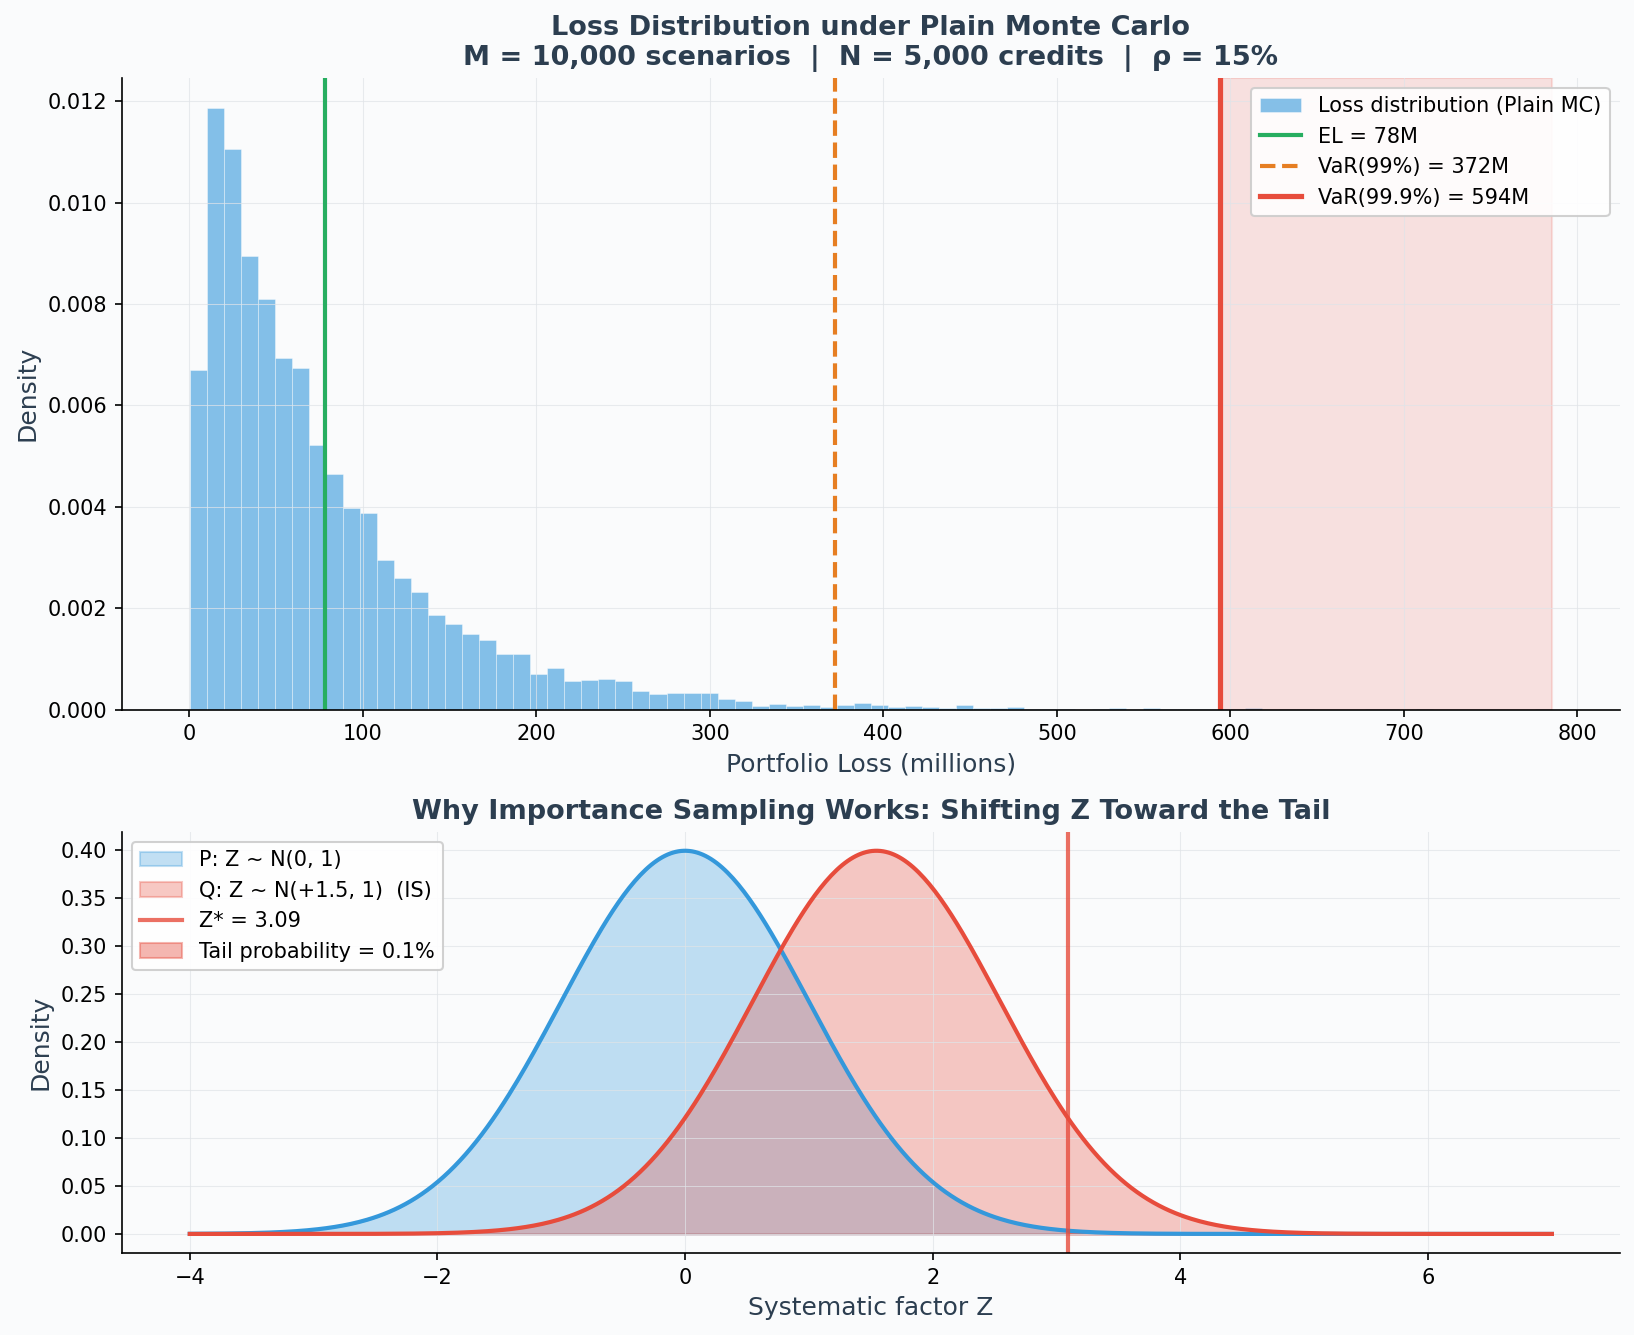

In [18]:
# === Loss Distribution and IS Visualization ===

fig, axes = plt.subplots(2, 1, figsize=(11, 9), dpi=150,
                         gridspec_kw={'height_ratios': [3, 2]})

C = {'bg': '#FAFBFC', 'grid': '#E0E4E8', 'text': '#2C3E50',
     'el': '#27AE60', 'var99': '#E67E22', 'var999': '#E74C3C',
     'plain': '#3498DB'}

fig.patch.set_facecolor(C['bg'])
for ax in axes: ax.set_facecolor(C['bg'])

# ---- TOP: Loss distribution histogram ----
ax = axes[0]
ax.hist(L_plain / 1e6, bins=80, density=True, alpha=0.6,
        color=C['plain'], edgecolor='white', linewidth=0.3,
        label='Loss distribution (Plain MC)')

ax.axvline(EL / 1e6, color=C['el'], ls='-', lw=2,
           label=f'EL = {EL/1e6:,.0f}M')
ax.axvline(VaR_99 / 1e6, color=C['var99'], ls='--', lw=2,
           label=f'VaR(99%) = {VaR_99/1e6:,.0f}M')
ax.axvline(VaR_999 / 1e6, color=C['var999'], ls='-', lw=2.5,
           label=f'VaR(99.9%) = {VaR_999/1e6:,.0f}M')

if L_plain.max() > VaR_999:
    ax.axvspan(VaR_999/1e6, L_plain.max()/1e6, alpha=0.15, color=C['var999'])

ax.set_xlabel('Portfolio Loss (millions)', fontsize=12, color=C['text'])
ax.set_ylabel('Density', fontsize=12, color=C['text'])
ax.set_title('Loss Distribution under Plain Monte Carlo\n'
             f'M = {M_demo:,} scenarios  |  N = {N:,} credits  |  '
             f'\u03c1 = {rho:.0%}',
             fontsize=13, color=C['text'], fontweight='bold')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.grid(True, color=C['grid'], lw=0.5, alpha=0.7)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# ---- BOTTOM: Z distributions (P vs Q) ----
ax2 = axes[1]
z_range = np.linspace(-4, 7, 500)
pdf_P = norm.pdf(z_range)
pdf_Q = norm.pdf(z_range, loc=shift_IS)

ax2.fill_between(z_range, pdf_P, alpha=0.3, color='#3498DB',
                 label='P: Z ~ N(0, 1)')
ax2.plot(z_range, pdf_P, color='#3498DB', lw=2)
ax2.fill_between(z_range, pdf_Q, alpha=0.3, color='#E74C3C',
                 label=f'Q: Z ~ N({shift_IS:+.1f}, 1)  (IS)')
ax2.plot(z_range, pdf_Q, color='#E74C3C', lw=2)

ax2.axvline(z_alpha, color=C['var999'], ls='-', lw=2, alpha=0.8,
            label=f'Z* = {z_alpha:.2f}')
tail_z = z_range[z_range >= z_alpha]
ax2.fill_between(tail_z, norm.pdf(tail_z), alpha=0.4, color='#E74C3C',
                 label='Tail probability = 0.1%')

ax2.set_xlabel('Systematic factor Z', fontsize=12, color=C['text'])
ax2.set_ylabel('Density', fontsize=12, color=C['text'])
ax2.set_title('Why Importance Sampling Works: Shifting Z Toward the Tail',
              fontsize=13, color=C['text'], fontweight='bold')
ax2.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax2.grid(True, color=C['grid'], lw=0.5, alpha=0.7)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('loss_distribution.png', dpi=300, bbox_inches='tight',
            facecolor=C['bg'])
print('Saved: loss_distribution.png')
plt.show()

In [19]:
# === Method Comparison at M = 10,000 ===

L_plain_sorted = np.sort(L_plain)
var_p_99  = L_plain_sorted[int(0.99 * M_demo) - 1]
var_p_999 = L_plain_sorted[int(0.999 * M_demo) - 1]

def weighted_percentile(losses, lr, alpha_val):
    order = losses.argsort()
    L_s = losses[order]
    pr = lr[order] / lr[order].sum()
    cum = np.cumsum(pr[::-1])[::-1]
    idx = min(np.searchsorted(-cum, -(1 - alpha_val)), len(L_s) - 1)
    return L_s[idx]

var_is_99  = weighted_percentile(L_is, lr_is, 0.99)
var_is_999 = weighted_percentile(L_is, lr_is, 0.999)
var_qmc_99  = weighted_percentile(L_qmc, lr_qmc, 0.99)
var_qmc_999 = weighted_percentile(L_qmc, lr_qmc, 0.999)

print(f'Comparison at M = {M_demo:,} (single run)')
print('=' * 75)
fmt = '{:>20s}  {:>14s}  {:>14s}  {:>14s}  {:>14s}'
print(fmt.format('', 'Exact', 'Plain MC', 'IS', 'IS+QMC'))
print('-' * 75)
fmt_n = '{:>20s}  {:>14,.0f}  {:>14,.0f}  {:>14,.0f}  {:>14,.0f}'
print(fmt_n.format('VaR(99%)', VaR_99, var_p_99, var_is_99, var_qmc_99))
print(fmt_n.format('VaR(99.9%)', VaR_999, var_p_999, var_is_999, var_qmc_999))
print('-' * 75)
err_p = (var_p_999 - VaR_999) / VaR_999
err_i = (var_is_999 - VaR_999) / VaR_999
err_q = (var_qmc_999 - VaR_999) / VaR_999
fmt_e = '{:>20s}  {:>14s}  {:>+14.2%}  {:>+14.2%}  {:>+14.2%}'
print(fmt_e.format('Error 99.9%', '---', err_p, err_i, err_q))

Comparison at M = 10,000 (single run)
                               Exact        Plain MC              IS          IS+QMC
---------------------------------------------------------------------------
            VaR(99%)     372,176,186     373,196,562     378,012,783     372,267,643
          VaR(99.9%)     593,716,870     610,326,409     603,365,318     594,226,971
---------------------------------------------------------------------------
         Error 99.9%             ---          +2.80%          +1.63%          +0.09%


## 8. Convergence Study

The single-run comparison in the previous section showed the three methods at work for one realization. But a single run does not tell us how **reliable** each method is. A lucky draw can make Plain MC look good; an unlucky one can make IS look bad.

To measure reliability, we repeat each estimator $R = 20$ times (with different random seeds) at each simulation size $M$, and compute the **Root Mean Square Error**:

$$\text{RMSE}(M) = \sqrt{\frac{1}{R}\sum_{r=1}^{R}\left(\widehat{VaR}^{(r)}_M - VaR_{\text{exact}}\right)^2}$$

We report the **relative RMSE** = RMSE / $VaR_{\text{exact}}$ $\times$ 100%, which tells us the typical percentage error for each method at each $M$.

### What to expect on the log-log plot

On a log-log scale, the convergence rate appears as the **slope** of the curve:

- **Plain MC**: slope $\approx -0.5$, corresponding to $O(1/\sqrt{M})$. Every 4x increase in $M$ halves the error.
- **IS**: same asymptotic slope ($-0.5$), but shifted downward by an order of magnitude. IS does not change the rate, but it reduces the constant dramatically.
- **IS + QMC**: slope $\approx -1.0$, corresponding to $O(1/M)$. Every 2x increase in $M$ halves the error. Combined with the already-lower constant from IS, this produces errors that are two orders of magnitude smaller than Plain MC at the same $M$.

> **Runtime note.** The cell below takes 1–3 hours on a typical laptop, mostly due to the Halton sequence generation in pure Python at large $M$. If you need faster results, reduce `n_reps` to 10 or remove the last 2–3 entries from `M_values`.

In [29]:
# === 8. CONVERGENCE STUDY ===

M_values = np.array([500, 1_000, 2_000, 3_000, 5_000,
                     7_500, 10_000, 15_000, 20_000, 50_000])

n_reps = 20

print(f'Configuration:')
print(f'  Sizes : {len(M_values)} points, {M_values[0]:,} to {M_values[-1]:,}')
print(f'  Reps  : {n_reps} per method')
print(f'  Total : {len(M_values) * n_reps * 3:,} estimations')
print()

# Pre-compute Halton for largest M
print('Pre-computing Halton sequence...', end=' ')
t0 = time.time()
halton_full = halton_sequence(M_values[-1], base=2)
halton_full = np.clip(halton_full, 1e-12, 1 - 1e-12)
halton_Z_full = norm.ppf(halton_full)
print(f'done ({time.time()-t0:.1f}s)')
print()


def var_qmc_cached(M, seed):
    '''IS+QMC using pre-computed Halton.'''
    Z = halton_Z_full[:M] + shift_IS
    lr = np.exp(-shift_IS * Z + shift_IS**2 / 2)
    L = cond_loss(Z)
    order = L.argsort()
    L_s, lr_s = L[order], lr[order]
    pr = lr_s / lr_s.sum()
    cum = np.cumsum(pr[::-1])[::-1]
    return L_s[min(np.searchsorted(-cum, -(1-alpha)), M-1)]


# -- Run --
rmse = np.zeros((3, len(M_values)))

t_total = time.time()
for i, M in enumerate(M_values):
    t0 = time.time()
    sq = np.zeros((3, n_reps))

    for r in range(n_reps):
        sd = r * 104729 + i * 31 + MASTER_SEED
        sq[0, r] = (var_plain_mc(M, sd)              - L_exact)**2
        sq[1, r] = (var_importance_sampling(M, sd+1)  - L_exact)**2
        sq[2, r] = (var_qmc_cached(M, sd+2)           - L_exact)**2

    for k in range(3):
        rmse[k, i] = np.sqrt(sq[k].mean())

    rr = rmse[:, i] / L_exact * 100
    dt = time.time() - t0
    print(f'  M = {M:>7,}   Plain: {rr[0]:>7.3f}%   IS: {rr[1]:>7.3f}%'
          f'   IS+QMC: {rr[2]:>7.3f}%   ({dt:.1f}s)')

rel_plain = rmse[0] / L_exact * 100
rel_is    = rmse[1] / L_exact * 100
rel_qmc   = rmse[2] / L_exact * 100

total_time = time.time() - t_total
print(f'\nTotal runtime: {total_time:.0f}s ({total_time/60:.1f} min)')
print(f'\nFinal RMSE at M = {M_values[-1]:,}:')
print(f'  Plain MC   : {rel_plain[-1]:.4f}%')
print(f'  IS         : {rel_is[-1]:.4f}%')
print(f'  IS + QMC   : {rel_qmc[-1]:.4f}%')
speedup = rel_plain[-1] / max(rel_qmc[-1], 1e-8)
print(f'  Speedup    : {speedup:.0f}x')

Configuration:
  Sizes : 10 points, 500 to 50,000
  Reps  : 20 per method
  Total : 600 estimations

Pre-computing Halton sequence... done (0.1s)

  M =     500   Plain:  21.588%   IS:   3.651%   IS+QMC:   2.173%   (9.0s)
  M =   1,000   Plain:  16.577%   IS:   2.798%   IS+QMC:   1.214%   (16.9s)
  M =   2,000   Plain:  11.591%   IS:   2.509%   IS+QMC:   0.746%   (34.8s)
  M =   3,000   Plain:   8.105%   IS:   1.484%   IS+QMC:   0.400%   (51.8s)
  M =   5,000   Plain:   6.804%   IS:   0.534%   IS+QMC:   0.058%   (88.8s)
  M =   7,500   Plain:   6.438%   IS:   0.778%   IS+QMC:   0.114%   (128.0s)
  M =  10,000   Plain:   4.066%   IS:   1.066%   IS+QMC:   0.086%   (173.3s)
  M =  15,000   Plain:   3.404%   IS:   0.806%   IS+QMC:   0.058%   (253.9s)
  M =  20,000   Plain:   3.439%   IS:   0.598%   IS+QMC:   0.029%   (336.9s)
  M =  50,000   Plain:   2.054%   IS:   0.422%   IS+QMC:   0.008%   (852.5s)

Total runtime: 1946s (32.4 min)

Final RMSE at M = 50,000:
  Plain MC   : 2.0540%
  IS  

Saved: convergence_var999.png (300 dpi)


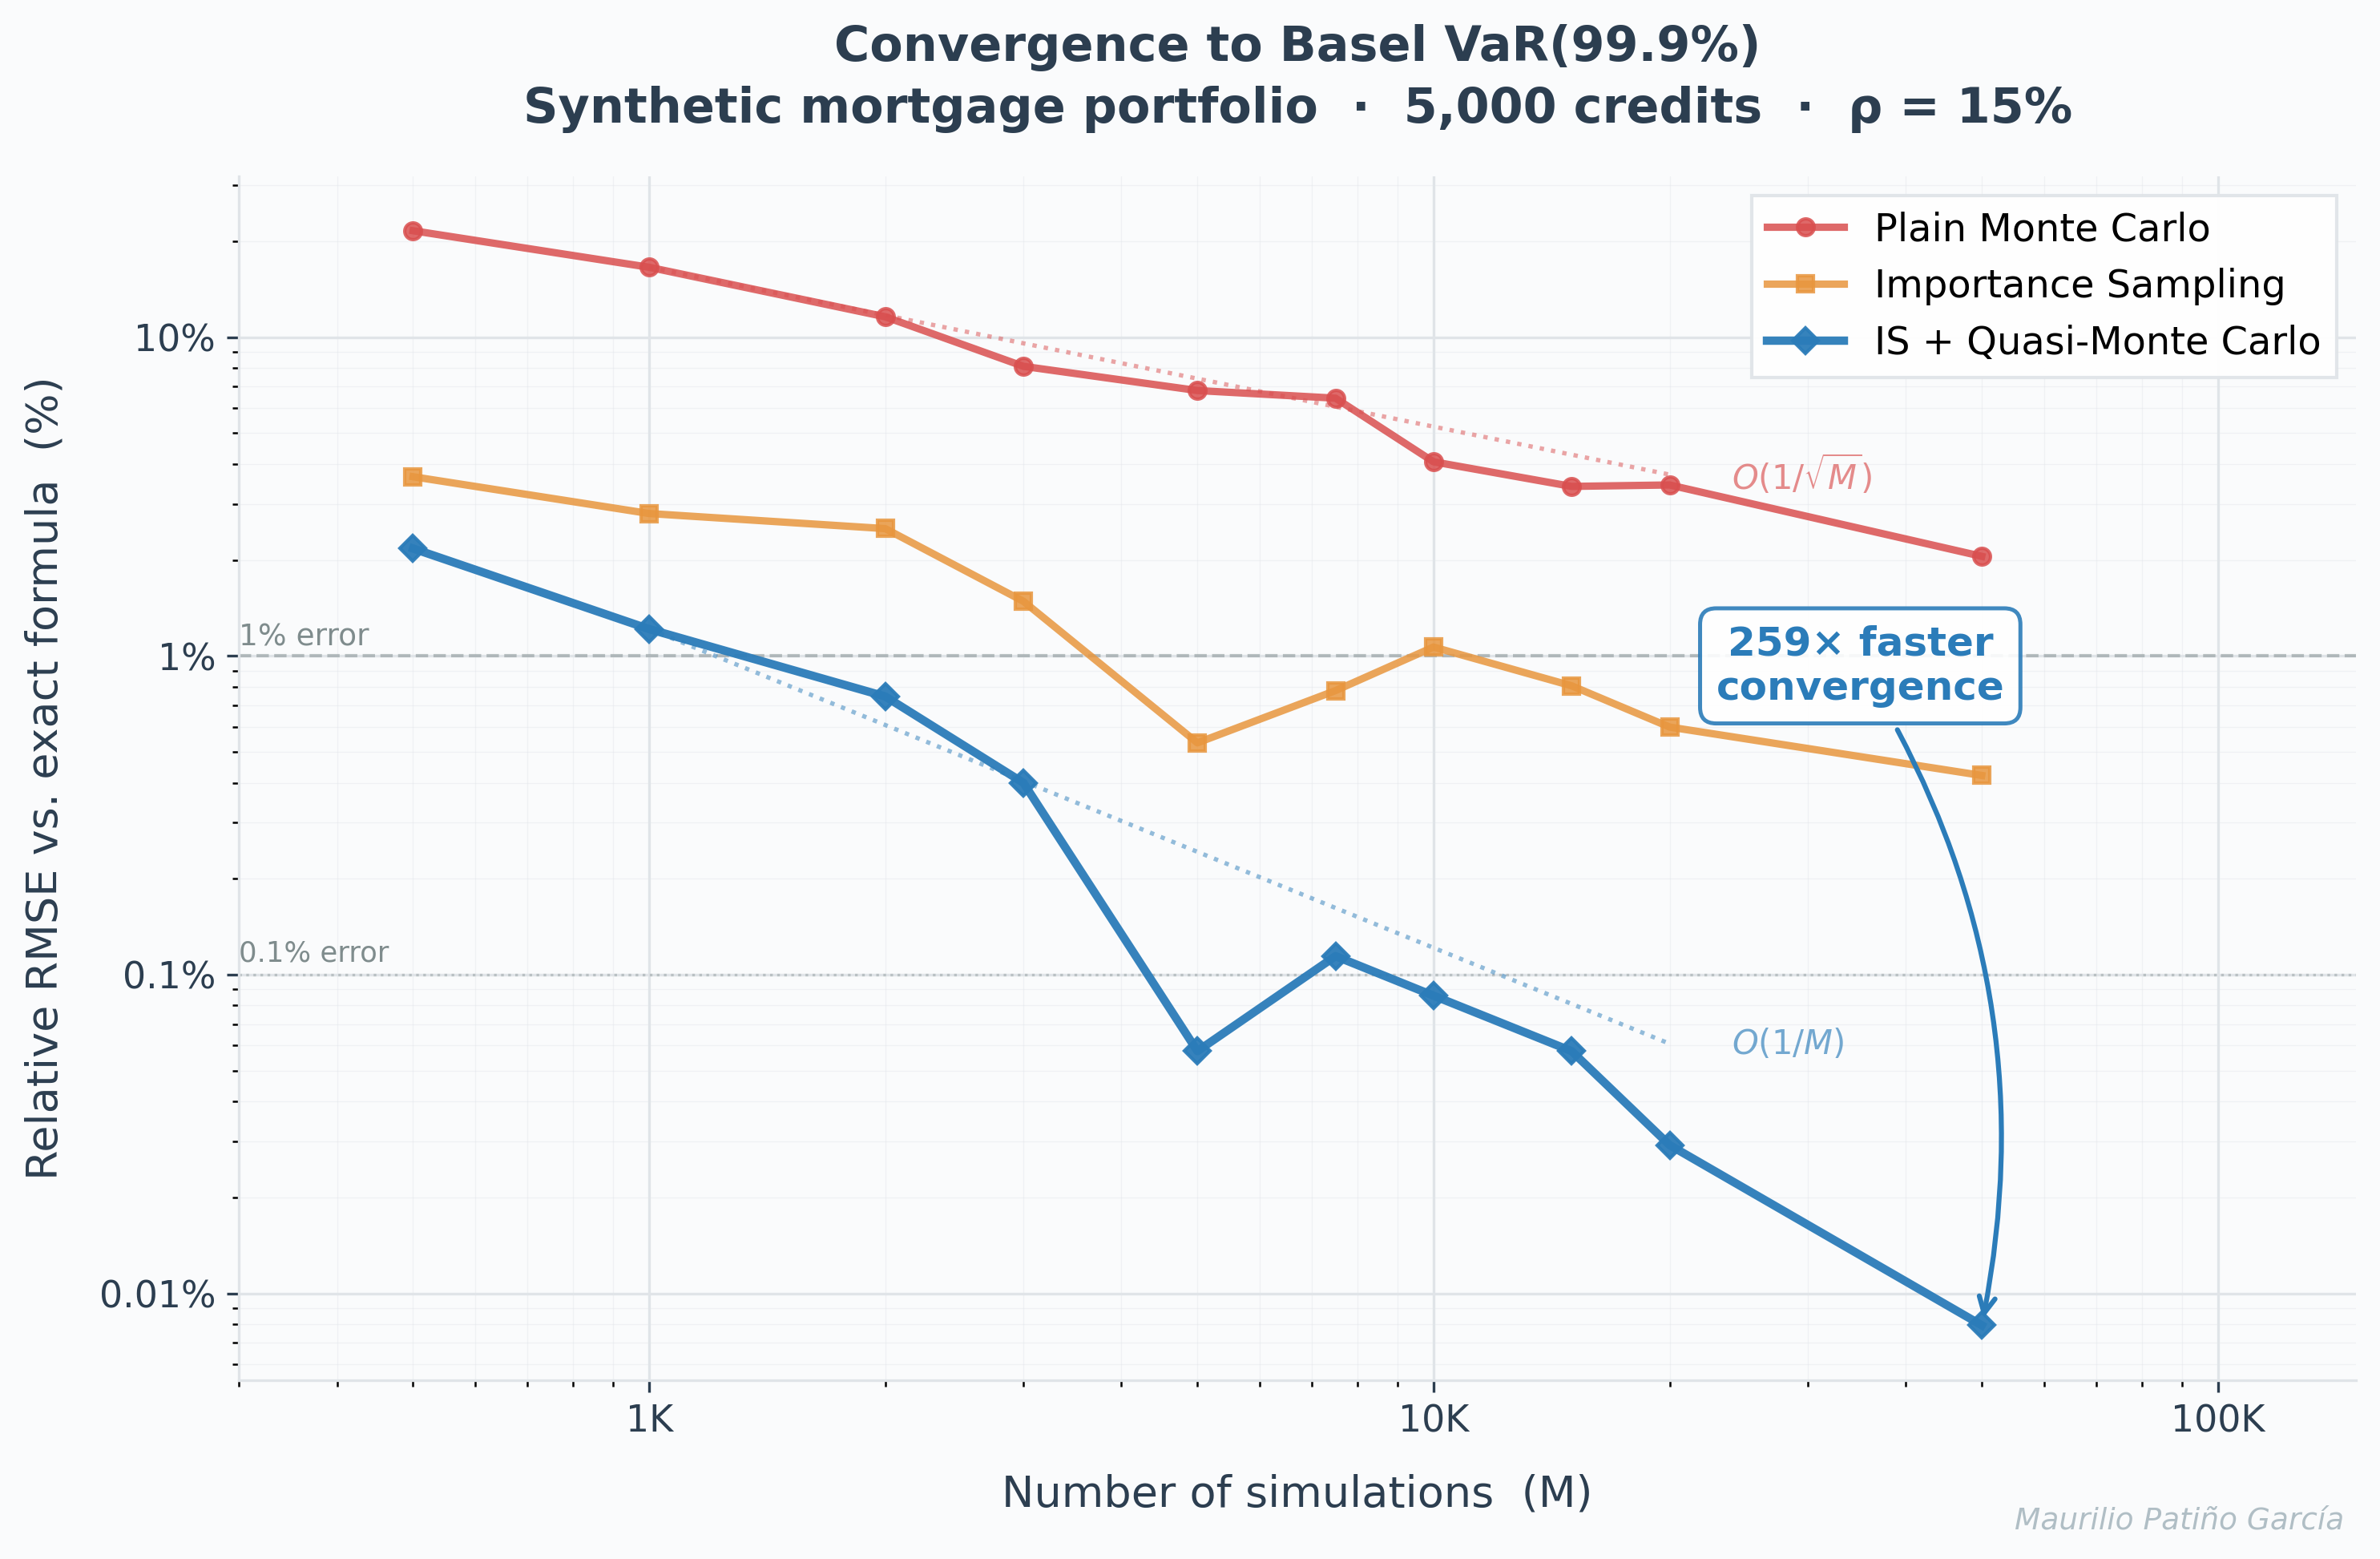

In [30]:
# === CONVERGENCE PLOT ===

COLORS = {
    'plain': '#D94F4F', 'is': '#E8963E', 'qmc': '#2B7CB9',
    'bg': '#FAFBFC', 'grid': '#E0E4E8', 'text': '#2C3E50', 'ann': '#7F8C8D'}

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=300)
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

ax.plot(M_values, rel_plain, 'o-', color=COLORS['plain'], lw=2.2, ms=5,
        label='Plain Monte Carlo', zorder=3, alpha=0.85)
ax.plot(M_values, rel_is, 's-', color=COLORS['is'], lw=2.2, ms=5,
        label='Importance Sampling', zorder=3, alpha=0.85)
ax.plot(M_values, rel_qmc, 'D-', color=COLORS['qmc'], lw=2.5, ms=5.5,
        label='IS + Quasi-Monte Carlo', zorder=4, alpha=0.95)

ax.axhline(y=1.0, color=COLORS['ann'], ls='--', lw=1, alpha=0.5, zorder=2)
ax.text(M_values[0]*0.6, 1.08, '1% error', fontsize=9, color=COLORS['ann'])
ax.axhline(y=0.1, color=COLORS['ann'], ls=':', lw=0.8, alpha=0.4, zorder=2)
ax.text(M_values[0]*0.6, 0.11, '0.1% error', fontsize=8.5, color=COLORS['ann'])

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Number of simulations  (M)', fontsize=13,
              color=COLORS['text'], fontweight='medium', labelpad=10)
ax.set_ylabel('Relative RMSE vs. exact formula  (%)', fontsize=13,
              color=COLORS['text'], fontweight='medium', labelpad=10)
ax.set_title('Convergence to Basel VaR(99.9%)\n'
             'Synthetic mortgage portfolio  \u00b7  5,000 credits  \u00b7  \u03c1 = 15%',
             fontsize=14.5, color=COLORS['text'], fontweight='bold',
             pad=16, linespacing=1.4)

ax.grid(True, which='major', color=COLORS['grid'], lw=0.8, zorder=1)
ax.grid(True, which='minor', color=COLORS['grid'], lw=0.3, alpha=0.4, zorder=1)
ax.tick_params(axis='both', which='major', labelsize=11, colors=COLORS['text'])

ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, _: f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'))
def pct_fmt(y, _):
    if y >= 1: return f'{y:.0f}%'
    if y >= 0.1: return f'{y:.1f}%'
    return f'{y:.2f}%'
ax.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
ax.set_xlim(M_values[0]*0.6, M_values[-1]*3)

# Theoretical slopes
i_ref = 1
xr = np.array([M_values[i_ref], M_values[-2]])
y_half = rel_plain[i_ref] * (xr / xr[0])**(-0.5)
ax.plot(xr, y_half, ':', color=COLORS['plain'], lw=1.3, alpha=0.5)
ax.text(xr[-1]*1.2, y_half[-1], r'$O(1/\sqrt{M})$',
        fontsize=10, color=COLORS['plain'], alpha=0.65, va='center')
y_one = rel_qmc[i_ref] * (xr / xr[0])**(-1.0)
ax.plot(xr, y_one, ':', color=COLORS['qmc'], lw=1.3, alpha=0.5)
ax.text(xr[-1]*1.2, y_one[-1], r'$O(1/M)$',
        fontsize=10, color=COLORS['qmc'], alpha=0.65, va='center')

# Speedup annotation: boxed, in the open space at the right
speedup = rel_plain[-1] / max(rel_qmc[-1], 1e-8)
ax.annotate(f'{speedup:.0f}\u00d7 faster\nconvergence',
            xy=(M_values[-1], rel_qmc[-1]),
            xytext=(M_values[-1]*0.7, np.sqrt(rel_plain[-1] * rel_is[-1])),
            fontsize=12, fontweight='bold', color=COLORS['qmc'],
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=COLORS['qmc'], alpha=0.9, lw=1.2),
            arrowprops=dict(arrowstyle='->', color=COLORS['qmc'],
                            lw=1.5, connectionstyle='arc3,rad=-0.2'),
            zorder=6)

leg = ax.legend(fontsize=11.5, loc='upper right', frameon=True,
                fancybox=False, edgecolor=COLORS['grid'],
                facecolor='white', framealpha=0.95)
leg.get_frame().set_linewidth(1.0)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax.spines[sp].set_color(COLORS['grid'])

fig.text(0.98, 0.01, 'Maurilio Pati\u00f1o Garc\u00eda',
         fontsize=9, color='#B0BEC5', ha='right', va='bottom',
         fontstyle='italic')

plt.tight_layout()
plt.savefig('convergence_var999.png', dpi=300, bbox_inches='tight',
            facecolor=COLORS['bg'], edgecolor='none')
print('Saved: convergence_var999.png (300 dpi)')
plt.show()

## 9. Numerical Summary

In [31]:
# === 9. SUMMARY TABLE ===

rows = []
for i, M in enumerate(M_values):
    rows.append({
        'M': f'{M:,}',
        'Plain MC (%)': f'{rel_plain[i]:.3f}',
        'IS (%)': f'{rel_is[i]:.3f}',
        'IS+QMC (%)': f'{rel_qmc[i]:.3f}',
        'Speedup': f'{rel_plain[i] / max(rel_qmc[i], 1e-8):.1f}x',
    })

df = pd.DataFrame(rows)
print('Relative RMSE vs. exact Basel formula:')
print('=' * 65)
print(df.to_string(index=False))
print()
print(f'Exact VaR(99.9%) = {L_exact:,.0f}')

Relative RMSE vs. exact Basel formula:
     M Plain MC (%) IS (%) IS+QMC (%) Speedup
   500       21.588  3.651      2.173    9.9x
 1,000       16.577  2.798      1.214   13.7x
 2,000       11.591  2.509      0.746   15.5x
 3,000        8.105  1.484      0.400   20.3x
 5,000        6.804  0.534      0.058  118.2x
 7,500        6.438  0.778      0.114   56.3x
10,000        4.066  1.066      0.086   47.3x
15,000        3.404  0.806      0.058   59.2x
20,000        3.439  0.598      0.029  117.8x
50,000        2.054  0.422      0.008  258.7x

Exact VaR(99.9%) = 593,716,870


## Key Takeaways

### 1. The Basel formula is not an approximation — it is the exact answer for granular portfolios

The closed-form expression we derived in Post 1 is not a convenient shortcut or a regulatory simplification. It is the mathematically exact VaR of a portfolio in the limit of many, well-diversified exposures. This notebook used it as the **ground truth** against which every Monte Carlo estimator was measured. The fact that all three methods converge to the same number — and that IS+QMC gets there with less than 0.1% error — is itself a validation of the asymptotic result. If the formula were an approximation, the simulation would not agree with it so precisely.

For practitioners, the implication is direct: if your portfolio is granular (thousands of credits with no single dominant exposure), you do not need Monte Carlo to compute regulatory VaR. The formula gives you the answer in milliseconds. Monte Carlo becomes necessary only when the assumptions behind the formula break down — concentration, multiple factors, non-Gaussian shocks, or path-dependent features.

### 2. Importance Sampling eliminates wasted effort in the tail

The core insight of IS is simple: under the original distribution, 99.9% of simulated scenarios produce losses below the quantile we are trying to estimate. They consume computational resources but contribute no information about the tail. IS fixes this by shifting the sampling distribution toward the adverse region, so that a much larger fraction of scenarios falls where the VaR lives.

The correction — the likelihood ratio — ensures that the estimate remains unbiased despite the shift. And the choice of shift matters: centering $Q$ right on the quantile ($\mu = z^*$) creates extreme weights that destabilize the estimator; placing it halfway ($\mu \approx z^*/2$) balances tail coverage against weight variance. This is not a heuristic — it follows from the variance-minimizing analysis in Glasserman (2003).

The practical payoff is visible in the convergence plot: at every simulation count $M$, IS reduces the RMSE by roughly an order of magnitude compared to Plain MC, without increasing computational cost per scenario.

### 3. Quasi-Monte Carlo changes the rate, not just the constant

Importance Sampling improves the constant in the convergence rate but does not change its fundamental scaling: IS still converges as $O(1/\sqrt{M})$, meaning you need 4x the simulations to halve the error. Quasi-Monte Carlo changes the game by replacing pseudorandom draws with a low-discrepancy Halton sequence, achieving $O(1/M)$ convergence — halving the error with just 2x the simulations.

The Koksma-Hlawka inequality makes this precise: the integration error is bounded by the product of the function's variation and the sequence's discrepancy. Halton's discrepancy is $O(\log M / M)$, which is dramatically smaller than the $O(1/\sqrt{M})$ discrepancy of pseudorandom points.

Combined with IS, the effect is compounding: IS reduces the constant by an order of magnitude, and QMC doubles the convergence rate. The result, as the convergence plot shows, is that IS+QMC reaches sub-0.1% accuracy at simulation counts where Plain MC is still above 5%.


---

This is the second in a series on credit risk modeling.

---

**References:**

- G. Löffler, P. Posch. *Credit Risk Modeling using Excel and VBA*. Wiley, 2nd ed. **Chapter 7**: the VBA simulation framework that this notebook translates to Python.
- C. Bluhm, L. Overbeck, Ch. Wagner. *An Introduction to Credit Risk Modelling*. Chapman & Hall/CRC, 2003. Proposition 2.5.4 (asymptotic portfolio loss formula).
- P. Glasserman. *Monte Carlo Methods in Financial Engineering*. Springer, 2003. Chapter 4 (variance reduction), Chapter 5 (quasi-Monte Carlo).
- R.R. Bahadur. A note on quantiles in large samples. *Annals of Mathematical Statistics*, 37(3):577–580, 1966.
- Basel Committee. *An Explanatory Note on the Basel II IRB Risk Weight Functions*. BIS, 2005.